In [1]:
import glob
import os
import h5py
from maui_codebook import zdF, roi, visualizations
import numpy as np
import nibabel as nib
import time
from tqdm import trange
import matplotlib.pyplot as plt
import xarray as xr

In [23]:
experiment_path = '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly02_win01_trial0-001/'
file = glob.glob(f"{experiment_path}/*signals_260713.h5")[0]
with h5py.File(file, "r") as f:
    cluster_labels = f["labels"][...]
    # df = f["df"][...]
    signal = f["signal"][...]
    print(f.keys())
    # del f['df']
    print(f.keys())

<KeysViewHDF5 ['labels', 'signal']>
<KeysViewHDF5 ['labels', 'signal']>


In [3]:
import sys

In [16]:
print(f'{sys.getsizeof(cluster_labels) / 1000 / 1000} Mbytes')
print(f'{sys.getsizeof(signal) / 1000 / 1000} Mbytes')

23.0688 Mbytes
4.891184 Mbytes


In [29]:
new_hf = f"{experiment_path}/signals_sizecheck.h5"
f = h5py.File(f"{experiment_path}mytestfile.h5", "w")
f.create_dataset("labels", data=cluster_labels)
f.create_dataset("signal", data=signal)

<HDF5 dataset "signal": shape (11, 20, 2779), type "<f8">

In [52]:
directories = glob.glob('/Volumes/AhmedLab/princess/data/pIP10/processed/*')
for dir in directories:
    # print(dir)
    old_hf = f'{dir}/20_signals_260713.h5'
    # print(old_hf)
    new_hf = f'{dir}/20_supervoxels.h5'
    if glob.glob(old_hf):
        print(old_hf)
        os.remove(old_hf)
        if not glob.glob(new_hf):
            with h5py.File(old_hf, "r") as f:
                cluster_labels = f["labels"][...]
                # signal = f["signal"][...]
            f = h5py.File(new_hf, "w")
            f.create_dataset("labels", data=cluster_labels)
            # f.create_dataset("signal", data=signal)


/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260425_GC8m_fly04_win01_trial-001/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260425_GC8m_fly04_win02_trial-001/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260425_GC8m_fly05_win01_trial-001/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260427_GC8m_fly09_win02_trial-001/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-001/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-002/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260430_GC8m_fly11_win02_trial-001/20_signals_260713.h5
/Volumes/AhmedLab/princess/data/pIP10/processed/

In [30]:
def calculate_zscoredF_voxels(raw_array):
    # loop over every slice
    x_by_y = raw_array.shape[0] * raw_array.shape[1]
    window = raw_array.shape[-1]
    final_array = np.empty((raw_array.shape[2], x_by_y, window))

    for iSlice in range(raw_array.shape[2]):
        # collapse x and y
        array = raw_array[...,iSlice, :]
        voxel_array = array.reshape(x_by_y,-1)
        # print(voxel_array.shape)

        final_array[iSlice,:,:] = zdF._zdff(voxel_array, win = window, smooth = True)
    return final_array

def get_supervoxel_mean_2d(brain_slice, cluster_labels, n_clusters):
    # neural_data = brain_slice.shape[]  # make into vector

    signals = []
    cluster_idx = []

    for nn in range(n_clusters):
        idx = np.where(cluster_labels == nn)[0]
        mean_signal = np.nanmean(brain_slice[idx])

        signals.append(mean_signal)
        cluster_idx.append(idx)

    return np.asarray(signals), cluster_idx

In [32]:
nii_dir = f'{experiment_path}/motion_corrected_*.nii'

all_nii = glob.glob(nii_dir)
brain_array = np.empty([512,512,11,100], dtype=np.float32)

start_time = time.time()
for i in trange(brain_array.shape[-1]):
    single_nii = f'{experiment_path}/motion_corrected_volume{i}.nii'
    file = nib.load(single_nii) # shape (x, y, z)
    # for slice in range(brain_array.shape[-2]):
    # #     print(slice)
    #     data = file.dataobj[:,:,slice]
    #     if slice == 1:
    #         break
    data = file.get_fdata()
    brain_array[..., i] = data
    # # logger.debug(f"Assignment for slice: {i} took: {time.time() - t0}s")
    del data, file

print(f"Brain Array Assignment Completed in {time.time() - start_time}s")

df =calculate_zscoredF_voxels(brain_array)
del brain_array

  1%|          | 1/100 [00:01<02:28,  1.50s/it]


KeyboardInterrupt: 

In [30]:
print(df.shape) # (z, xy, t)
df[0].shape
print(cluster_labels.shape)

(11, 262144, 100)
(11, 262144)


In [41]:
# loop over slices, get_supervoxel_mean_2D, save as signals
n_clusters = 20
T = 100
signal = np.empty(shape=(df.shape[0], n_clusters, T))
for slice in range(df.shape[0]):
    mean_signal = np.empty(shape=(df.shape[2],n_clusters)) # t, z
    for vol in range(df.shape[2]):
        mean_supervox, _ = get_supervoxel_mean_2d(df[slice,:, vol], cluster_labels[slice], n_clusters)
        mean_signal[vol] = mean_supervox
    signal[slice] = mean_signal.T

/var/folders/6j/4hb4hfhs6ygdhcvnvsxhm5yr0000gs/T/ipykernel_4297/2482207029.py:24: RuntimeWarning: Mean of empty slice
  mean_signal = np.nanmean(brain_slice[idx])


(11, 20, 2779)


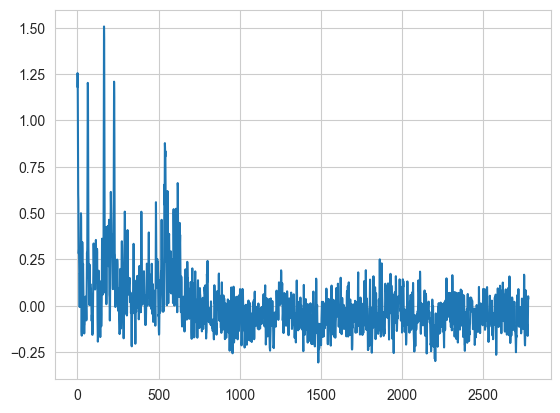

In [33]:
print(signal.shape)
plt.plot(signal[6,10])

In [4]:
# plot signals in one color, plot background in another color, save as png
file = '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly02_win01_trial0-001/20_signals_260713.h5'
with h5py.File(file, "r") as f:
    cluster_labels = f["labels"][...]
    signal = f["signal"][...]

In [36]:
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': range(signal.shape[2])}
)

In [34]:
import seaborn as sns
def plot_zscored_activity(clusters_toplot, signal_xarray):
    fig, ax = plt.subplots(figsize=(20, len(clusters_toplot)))
    yshift = 1
    # n_lines = len(clusters_toplot)
    palette_colors = sns.color_palette("Blues", len(clusters_toplot))

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color="b")

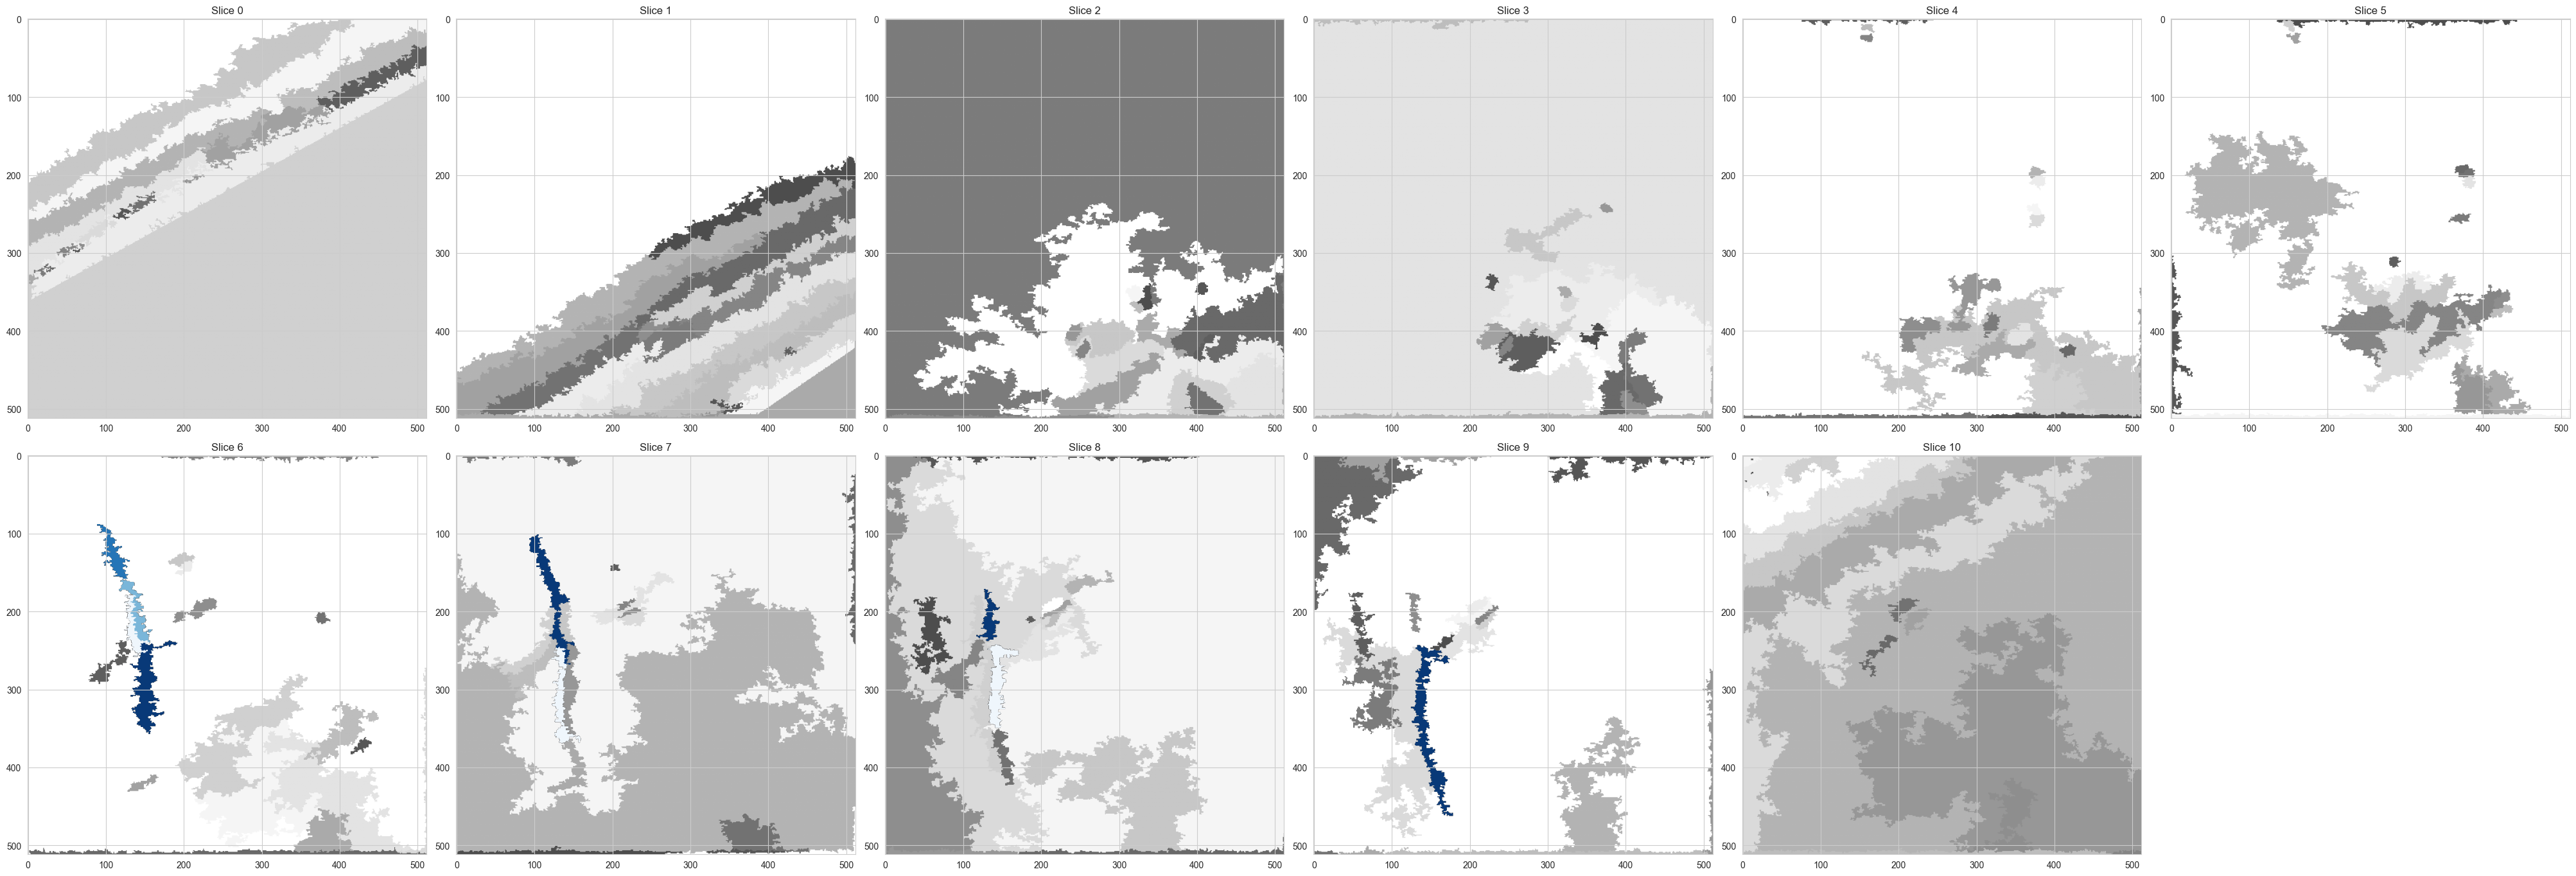

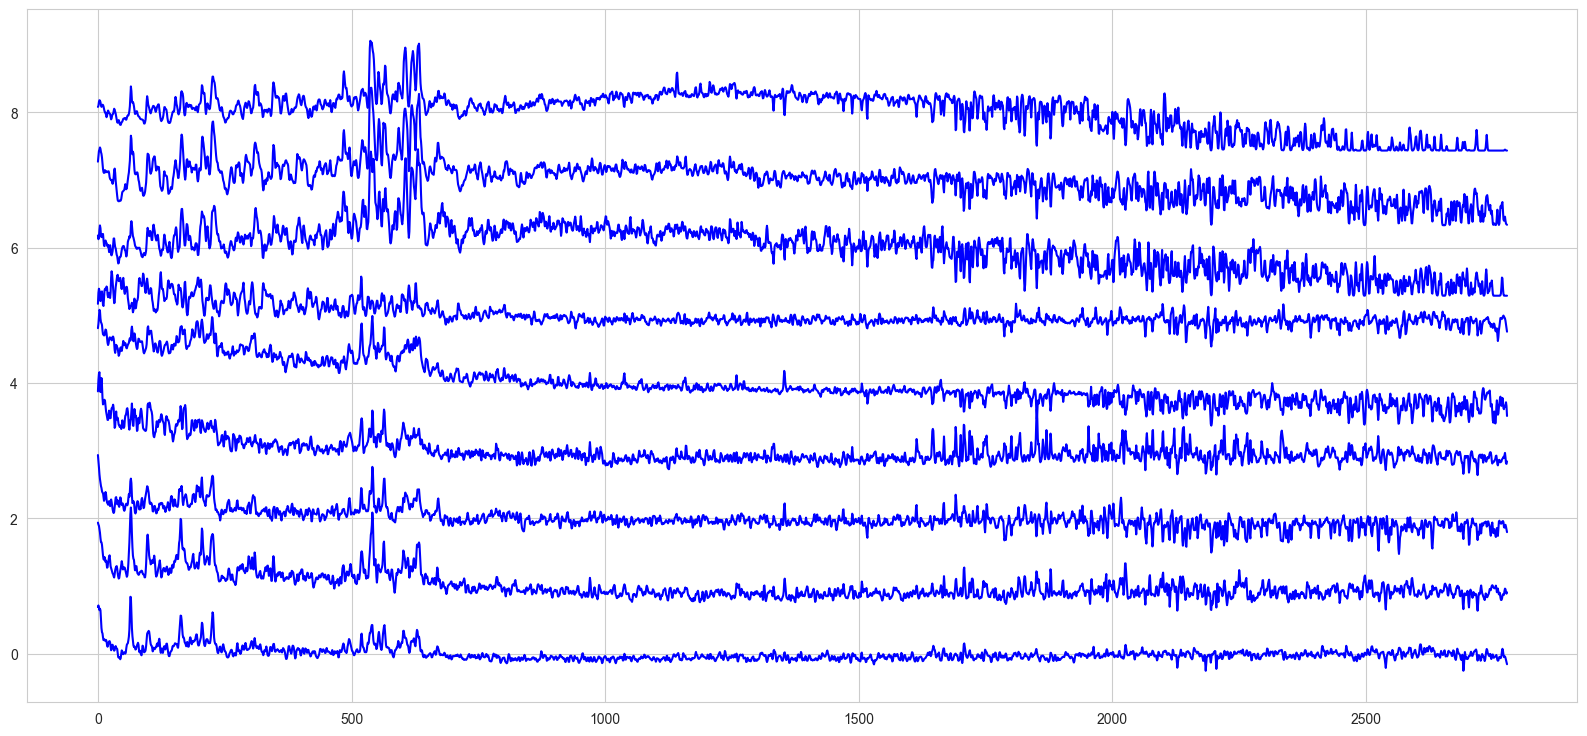

In [37]:
rois = [ [6,8], [6,14], [6,11], [6,19], [7,2], [7,10], [8,9],  [8,14], [9,6]]
dimensions = [512,512,11]
visualizations.plot_spatial_location(rois, cluster_labels, dimensions)
plot_zscored_activity(rois, signal_xr)